# Excercise 2a: Exploratory Data Analysis

In [2]:
import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
X_train = pd.read_csv("ex2_train.csv")
y_train = pd.read_csv("ex2_class_train.csv")
data = X_train.copy()
data['Survived'] = y_train

In [4]:
data.head()

,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,Survived
0,1,"Partner, Mr. Austen",male,45.5,0,0,28.5000,S,0
1,2,"Berriman, Mr. William John",male,23.0,0,0,13.0000,S,0
2,3,"Tikkanen, Mr. Juho",male,32.0,0,0,7.9250,S,0
3,3,"Hansen, Mr. Henrik Juul",male,26.0,1,0,7.8542,S,0
4,3,"Andersson, Miss. Ebba Iris Alfrida",female,6.0,4,2,31.2750,S,0


This is a widely used dataset that contains information on the passengers who were aboard the Titanic when it sank on its maiden voyage in 1912. We will use it for a supervised learning exercise (ex2b) to predict whether a passenger can survive based on his or her attributes. Before constructing the classifier, you need to do some guided exploratory data analysis in ex2a.

The column meanings are: 
* Survived: Survival status (0 = No, 1 = Yes).
* Pclass: Ticket class (1 = 1st, 2 = 2nd, 3 = 3rd).
* Name: Name of the passenger.
* Sex: Gender of the passenger (male/female).
* Age: Age of the passenger in years.
* SibSp: Number of siblings/spouses aboard the Titanic.
* Parch: Number of parents/children aboard the Titanic.
* Fare: Passenger fare.
* Embarked: Port of embarkation (C = Cherbourg, Q = Queenstown, S = Southampton).

**TODO: Please answer the following questions by using suitable analysis tools, e.g. statistics or visualizations.** To pass the exercise, you need to correctly answer three or more of Questions 1 to 5. A correct answer includes a correct statement and the analysis result that support the statement.

# Example Question: Is gender related to survival rate?

Answer: Yes, females had a higher survival rate.

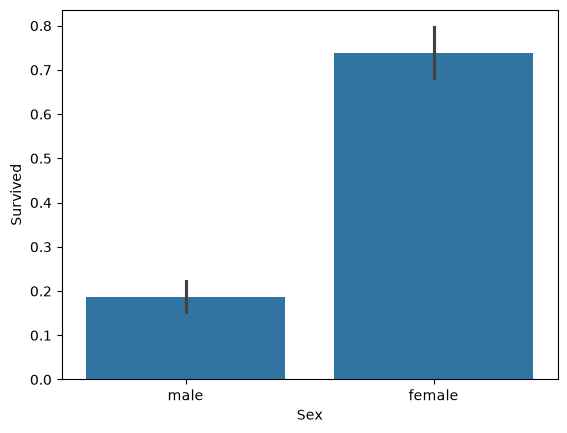

In [5]:
# Show the relevant statistics or visualization(s) to support your answer
sns.barplot(x='Sex', y='Survived', data=data)
plt.show()

# Question 1: Did first-class passengers survive more?

Answer: Yes, more first class passengers survived.

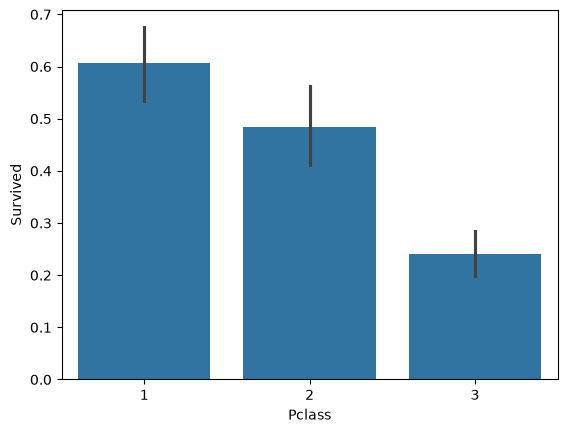

In [6]:
# Show the relevant statistics or visualization(s) to support your answer
sns.barplot(data=data, x='Pclass', y='Survived')
plt.show()

# Question 2: Is survival related to Embarked?

Answer: At first insight, survival rate in port C is higher than the other ports, but we have to take into consideration that most of the passengers of port Q are class 3, which ultimately lowers the survival rate based on the analysis before, so according to a visualization there is a relation between embarked and survival rate, but its not as sure to consider it determining.

Embarked  Pclass
C         1          57
          2          16
          3          52
Q         1           2
          2           3
          3          55
S         1         102
          2         132
          3         291
dtype: int64


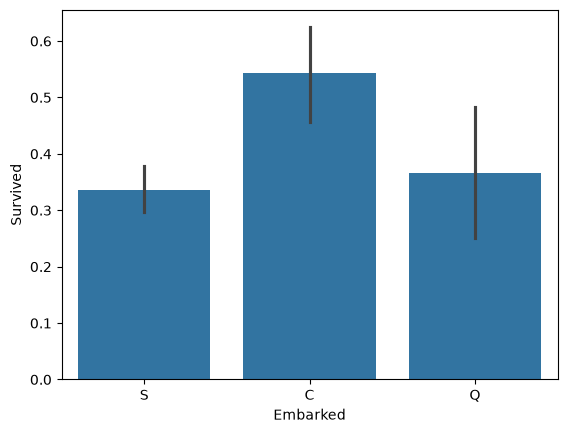

In [7]:
# Show the relevant statistics or visualization(s) to support your answer
print( data.groupby(['Embarked','Pclass']).size() )
sns.barplot(data=data, x='Embarked', y='Survived')
plt.show()

# Question 3: How is age related to survival?

Answer: The trend is pretty much the same (people of all ages died the same), but there is a spike at lower age intervals in survival rate, possibly for children priority of the lifesaving services available.

          survival_rate
AgeGroup               
[0, 10)        0.603774
[10, 20)       0.337662
[20, 30)       0.375691
[30, 40)       0.435115
[40, 50)       0.371429
[50, 60)       0.404762
[60, 70)       0.384615
[70, 80)       0.000000


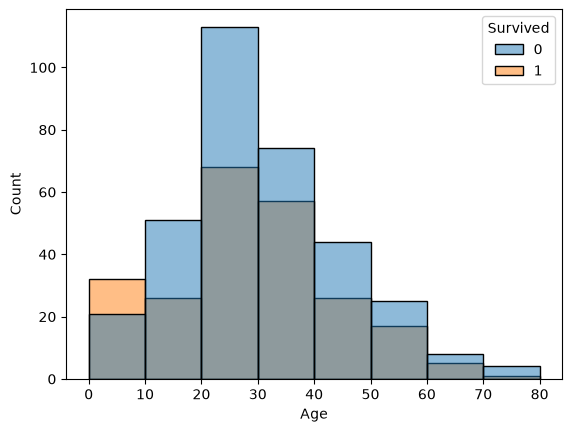

In [8]:
# Show the relevant statistics or visualization(s) to support your answer
bins = [0, 10, 20, 30, 40, 50, 60, 70, 80]
data['AgeGroup'] = pd.cut(data['Age'], bins=bins, right=False)

age_stats = data.groupby('AgeGroup', observed=False)['Survived'].agg(
    survival_rate='mean'
)
print(age_stats)

sns.histplot(data=data, x='Age', hue='Survived', bins=bins, common_norm=False, fill=True)
plt.show()

Note: the closer both bars of the same bin are from each other, the closer the survival rate is to 50%. 

# Question 4: Does family size somehow affect the survival rate?

Answer: It looks like so, as the family size increases (until family size of 4 people) the survival rate also increases.

<Axes: xlabel='FamilySize', ylabel='Survived'>

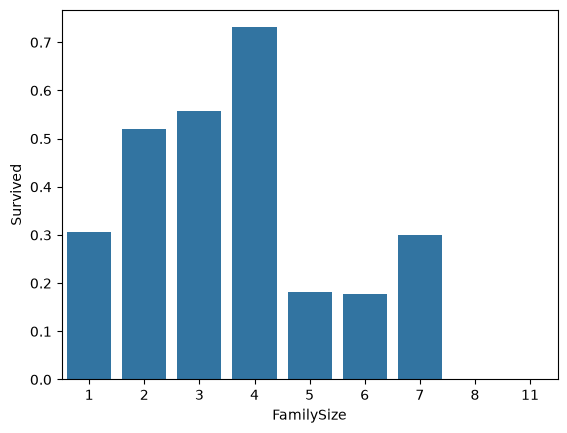

In [9]:
# Show the relevant statistics or visualization(s) to support your answer
data['FamilySize'] = data['SibSp'] + data['Parch'] + 1

family_stats = data.groupby('FamilySize', observed=False)['Survived'].agg(
    survival_rate='mean'
)
sns.barplot(data=data, x='FamilySize', y='Survived', errorbar=None)

# Question 5: Some passengers with certain titles seemed to have more chance to survive. Is that true?

Answer: It is clearly seen that the people corresponding to the title "Mr" (men) has the lowest rate overall, whilst "Miss", "Mrs" and "Master" have greater survival rate (more livesaving priority).

Other titles as "the Countess", "Lady" or Jonkheer (which title string regex extraction destroyed), members of the nobility, also survived.

Title
Mr              419
Miss            143
Mrs              96
Master           33
Rev               5
Dr                5
Major             2
Col               2
Mlle              2
Capt              1
Mme               1
Ms                1
the Countess      1
Lady              1
Name: count, dtype: int64


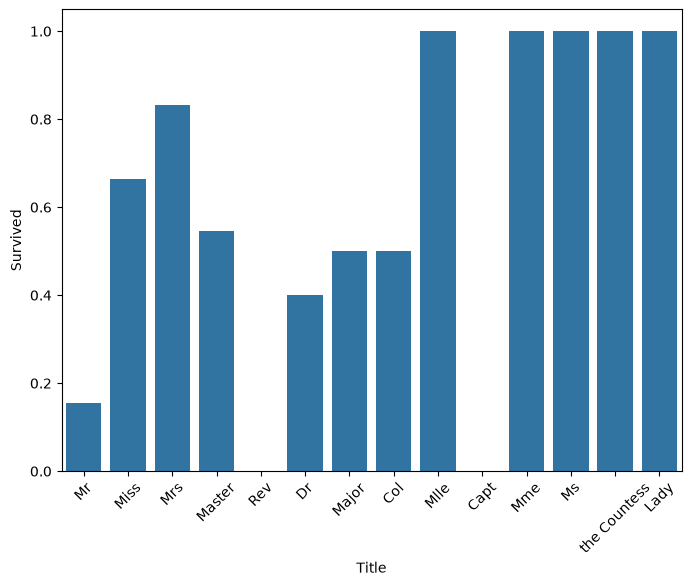

In [12]:
# Show the relevant statistics or visualization(s) to support your answer

data['Title'] = data['Name'].str.extract(r',\s*([^\.]+)\.', expand=False)

print(data['Title'].value_counts())

plt.figure(figsize=(8, 6))
plt.tight_layout()
plt.xticks(rotation=45)
sns.barplot(
    data=data, 
    x='Title', 
    y='Survived', 
    order=data["Title"].value_counts().index,
    errorbar=None)
plt.show()